In [10]:
import numpy as np
import matplotlib.pyplot as plt

from utils.data import generate_data
from utils.select_lib import get_proba, rejector, classifier
from utils.metrics import class_errors, balanced_error, worst_group_error, error
from utils.plot import plot_2D, plot_thresholds

In [ ]:
params = {
    "n_classes": 2,
    "n_samples": 1000,
    "means": [[-1, -1], [1, 1]],
    "covs": [np.eye(2), np.eye(2)],
    "priors": [0.5, 0.5],
    "seed": 42,
}

In [ ]:
def RC_curve(confidence, labels, pred, coverages):
    ber_vect = list()
    wg_vect = list()
    errors_vect = list()
    coverages_vect = list()

    for coverage in coverages:
        thr = np.percentile(confidence, (1 - coverage) * 100)
        accept_idx = rejector(confidence, thr)

        if np.unique(labels[accept_idx], return_counts=True)[1].min() > 25:
            coverages_vect.append(coverage)
            ber_vect.append(balanced_error(labels[accept_idx], pred[accept_idx]))
            wg_vect.append(worst_group_error(labels[accept_idx], pred[accept_idx]))
            errors_vect.append(error(labels[accept_idx], pred[accept_idx]))

    return coverages_vect, ber_vect, wg_vect, errors_vect


def plot_RC(coverages, ber, wg, errors):
    plt.plot(coverages, ber, marker="o", label="Balanced Error Rate")
    plt.plot(coverages, wg, marker="o", label="Worst Group Error")
    plt.plot(coverages, errors, marker="o", label="Regular Error Rate")
    plt.xlabel("Coverage")
    plt.ylabel("Error Rate")
    plt.title("Error Rates vs Coverage")
    plt.legend()
    plt.grid()
    plt.show()


def test_classifier(params, coverages):

    data, labels = generate_data(**params)

    plot_2D(data, labels, figsize=(6, 5))

    prob = get_proba(data, **params)
    pred, confidence = classifier(prob)

    cover_vect, ber_vect, wg_vect, errors_vect = RC_curve(
        confidence, labels, pred, coverages=coverages
    )

    return cover_vect, ber_vect, wg_vect, errors_vect

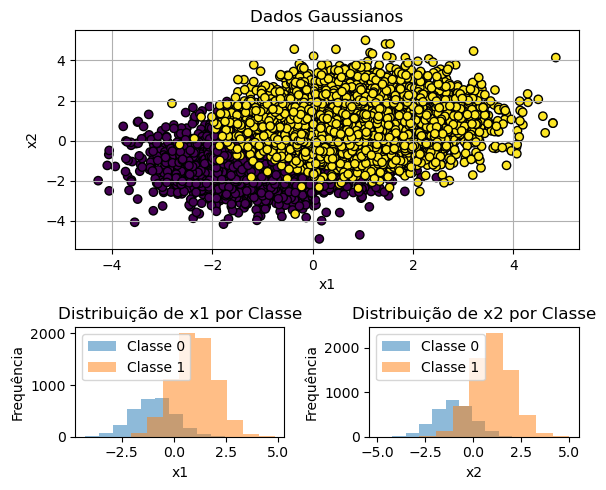

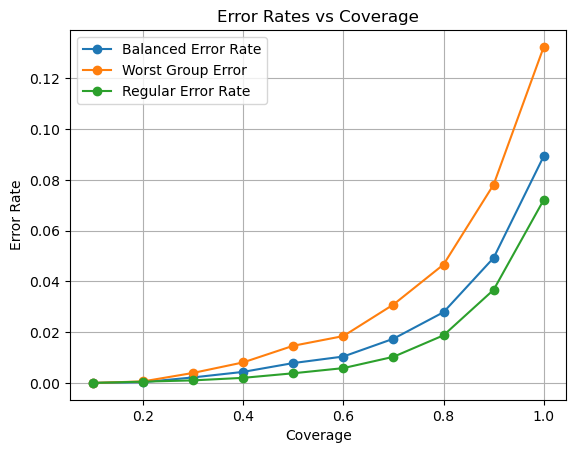

In [70]:
coverages = np.linspace(0.1, 1.0, 10)
cover, ber, wg, errors = test_classifier(params, coverages)

plot_RC(cover, ber, wg, errors)

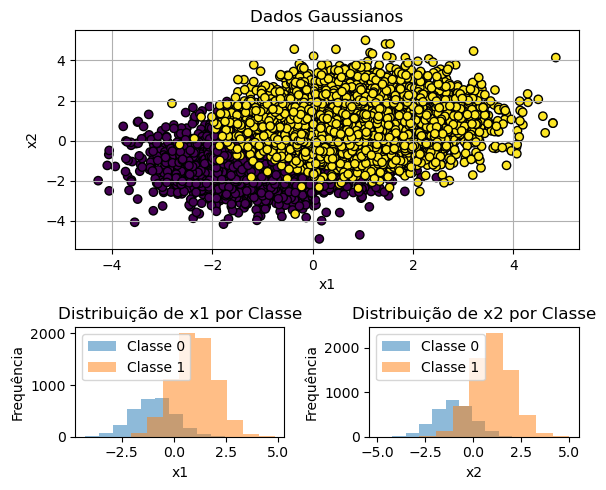

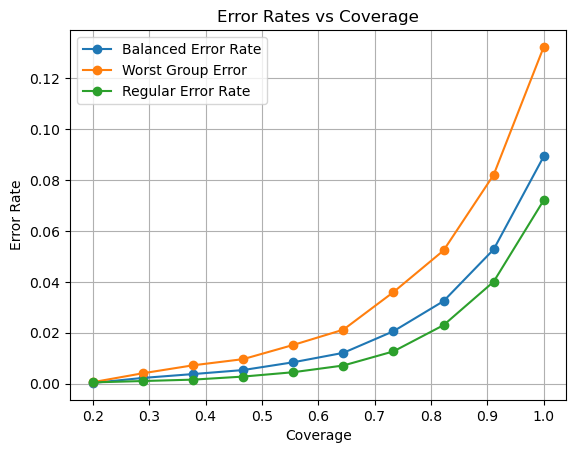

In [ ]:
params = {
    "n_classes": 2,
    "n_samples": 10000,
    "means": [[-1, -1], [1, 1]],
    "covs": [np.eye(2), np.eye(2)],
    "priors": [0.3, 0.7],
    "seed": 42,
}

coverages = np.linspace(0.2, 1.0, 10)

coverages, ber, wg, errors = test_classifier(params, coverages)
plot_RC(coverages, ber, wg, errors)